<a href="https://colab.research.google.com/github/ffahrialfikri/Data-Science-2026/blob/main/pertemuan3_fikrialfahri_250401020144.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nama: Fikri Alfahri NIM:250401020144 Kelas: IF405

Jumlah missing per kolom sebelum imputasi:
id               0
luas_m2         18
harga_juta      17
kota             0
kamar           10
tahun_bangun     0
kondisi          0
dtype: int64

Proporsi missing per kolom (yang > 0%):
luas_m2       13.85
harga_juta    13.08
kamar          7.69
dtype: float64

Shape sebelum drop kolom: (130, 7)
Shape setelah drop kolom: (130, 7)

Median sebelum imputasi:
luas_m2       193.8
harga_juta    655.0
kamar           4.0
dtype: float64

Jumlah missing values setelah imputasi:
luas_m2       0
harga_juta    0
kamar         0
dtype: int64

Beberapa baris pertama DataFrame setelah imputasi:


/tmp/ipykernel_2364/3814985439.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['luas_m2'].fillna(df['luas_m2'].median(), inplace=True)
/tmp/ipykernel_2364/3814985439.py:41: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,id,luas_m2,harga_juta,kota,kamar,tahun_bangun,kondisi
0,1,297.0,1084.0,jogja,2.0,2000,baik
1,2,254.0,761.0,Medan,4.0,1995,Bagus
2,3,249.7,895.0,Depok,4.0,1983,baik
3,4,49.7,178.0,YGY,5.0,2013,baik
4,5,133.4,424.0,Medan,5.0,2004,Sedang



Jumlah missing values akhir setelah semua proses (deteksi, drop kolom, dan imputasi):
id              0
luas_m2         0
harga_juta      0
kota            0
kamar           0
tahun_bangun    0
kondisi         0
dtype: int64

Shape DataFrame akhir: (130, 7)

[Selesai] Demonstrasi strategi imputasi statistik alternatif.
Jumlah missing values setelah demonstrasi:
id              0
luas_m2         0
harga_juta      0
kota            0
kamar           0
tahun_bangun    0
kondisi         0
dtype: int64
Shape DataFrame akhir: (130, 7)

Demonstrasi KNNImputer:
Beberapa baris pertama DataFrame setelah KNN Imputer (pada kolom numerik):


,luas_m2,harga_juta,kamar,tahun_bangun
0,297.0,1084.0,2.0,2000.0
1,254.0,761.0,4.0,1995.0
2,249.7,895.0,4.0,1983.0
3,49.7,178.0,5.0,2013.0
4,133.4,424.0,5.0,2004.0



Demonstrasi SimpleImputer (mean):
Beberapa baris pertama DataFrame setelah SimpleImputer (mean) pada kolom numerik:


,luas_m2,harga_juta,kamar,tahun_bangun
0,297.0,1084.0,2.0,2000.0
1,254.0,761.0,4.0,1995.0
2,249.7,895.0,4.0,1983.0
3,49.7,178.0,5.0,2013.0
4,133.4,424.0,5.0,2004.0



[Selesai] Demonstrasi Imputer Lanjutan.
Jumlah missing values setelah semua demonstrasi:
id              0
luas_m2         0
harga_juta      0
kota            0
kamar           0
tahun_bangun    0
kondisi         0
dtype: int64
Shape DataFrame akhir: (130, 7)
0 baris duplikat dari 130 total
Outlier: 3 baris
Batas: [-423, 1719]
Baris dihapus: 3
Shape awal: (130, 7)
id               0
luas_m2         18
harga_juta      17
kota             0
kamar           10
tahun_bangun     0
kondisi          0
dtype: int64
Setelah hapus duplikat: (130, 7)
Shape akhir: (130, 7)
Dataset bersih tersimpan!


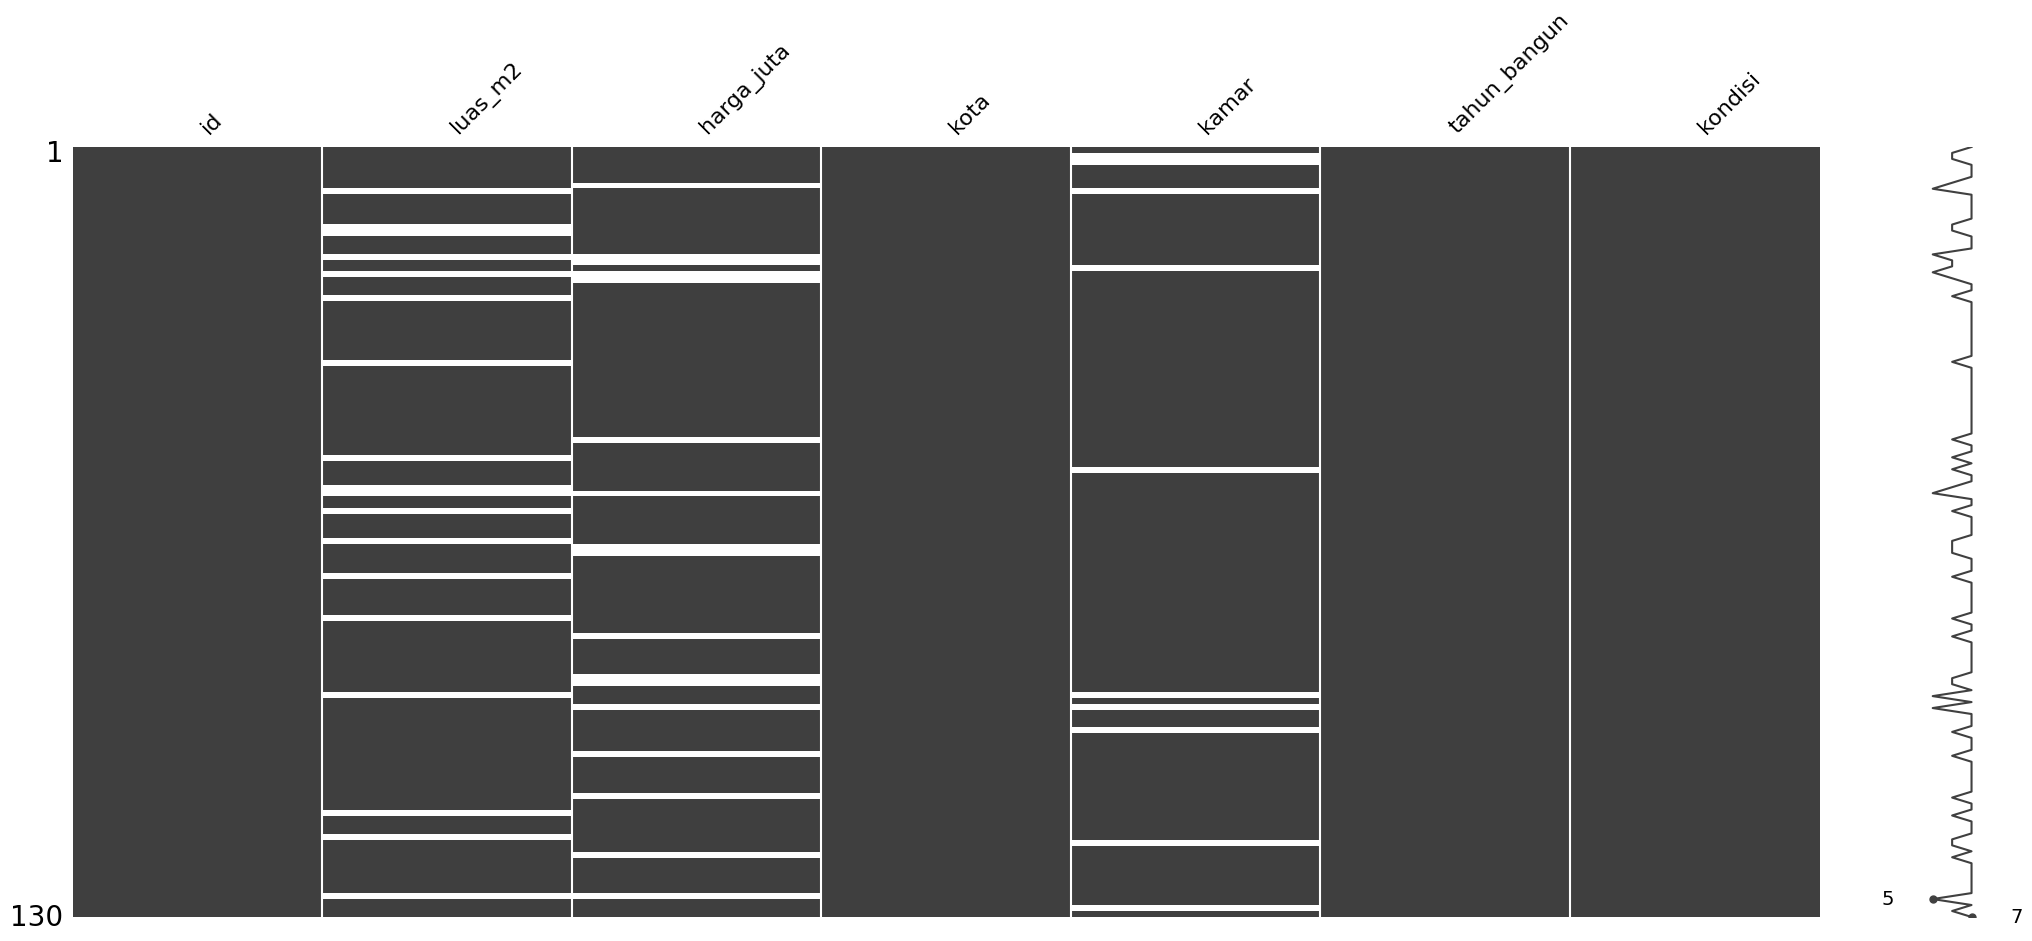

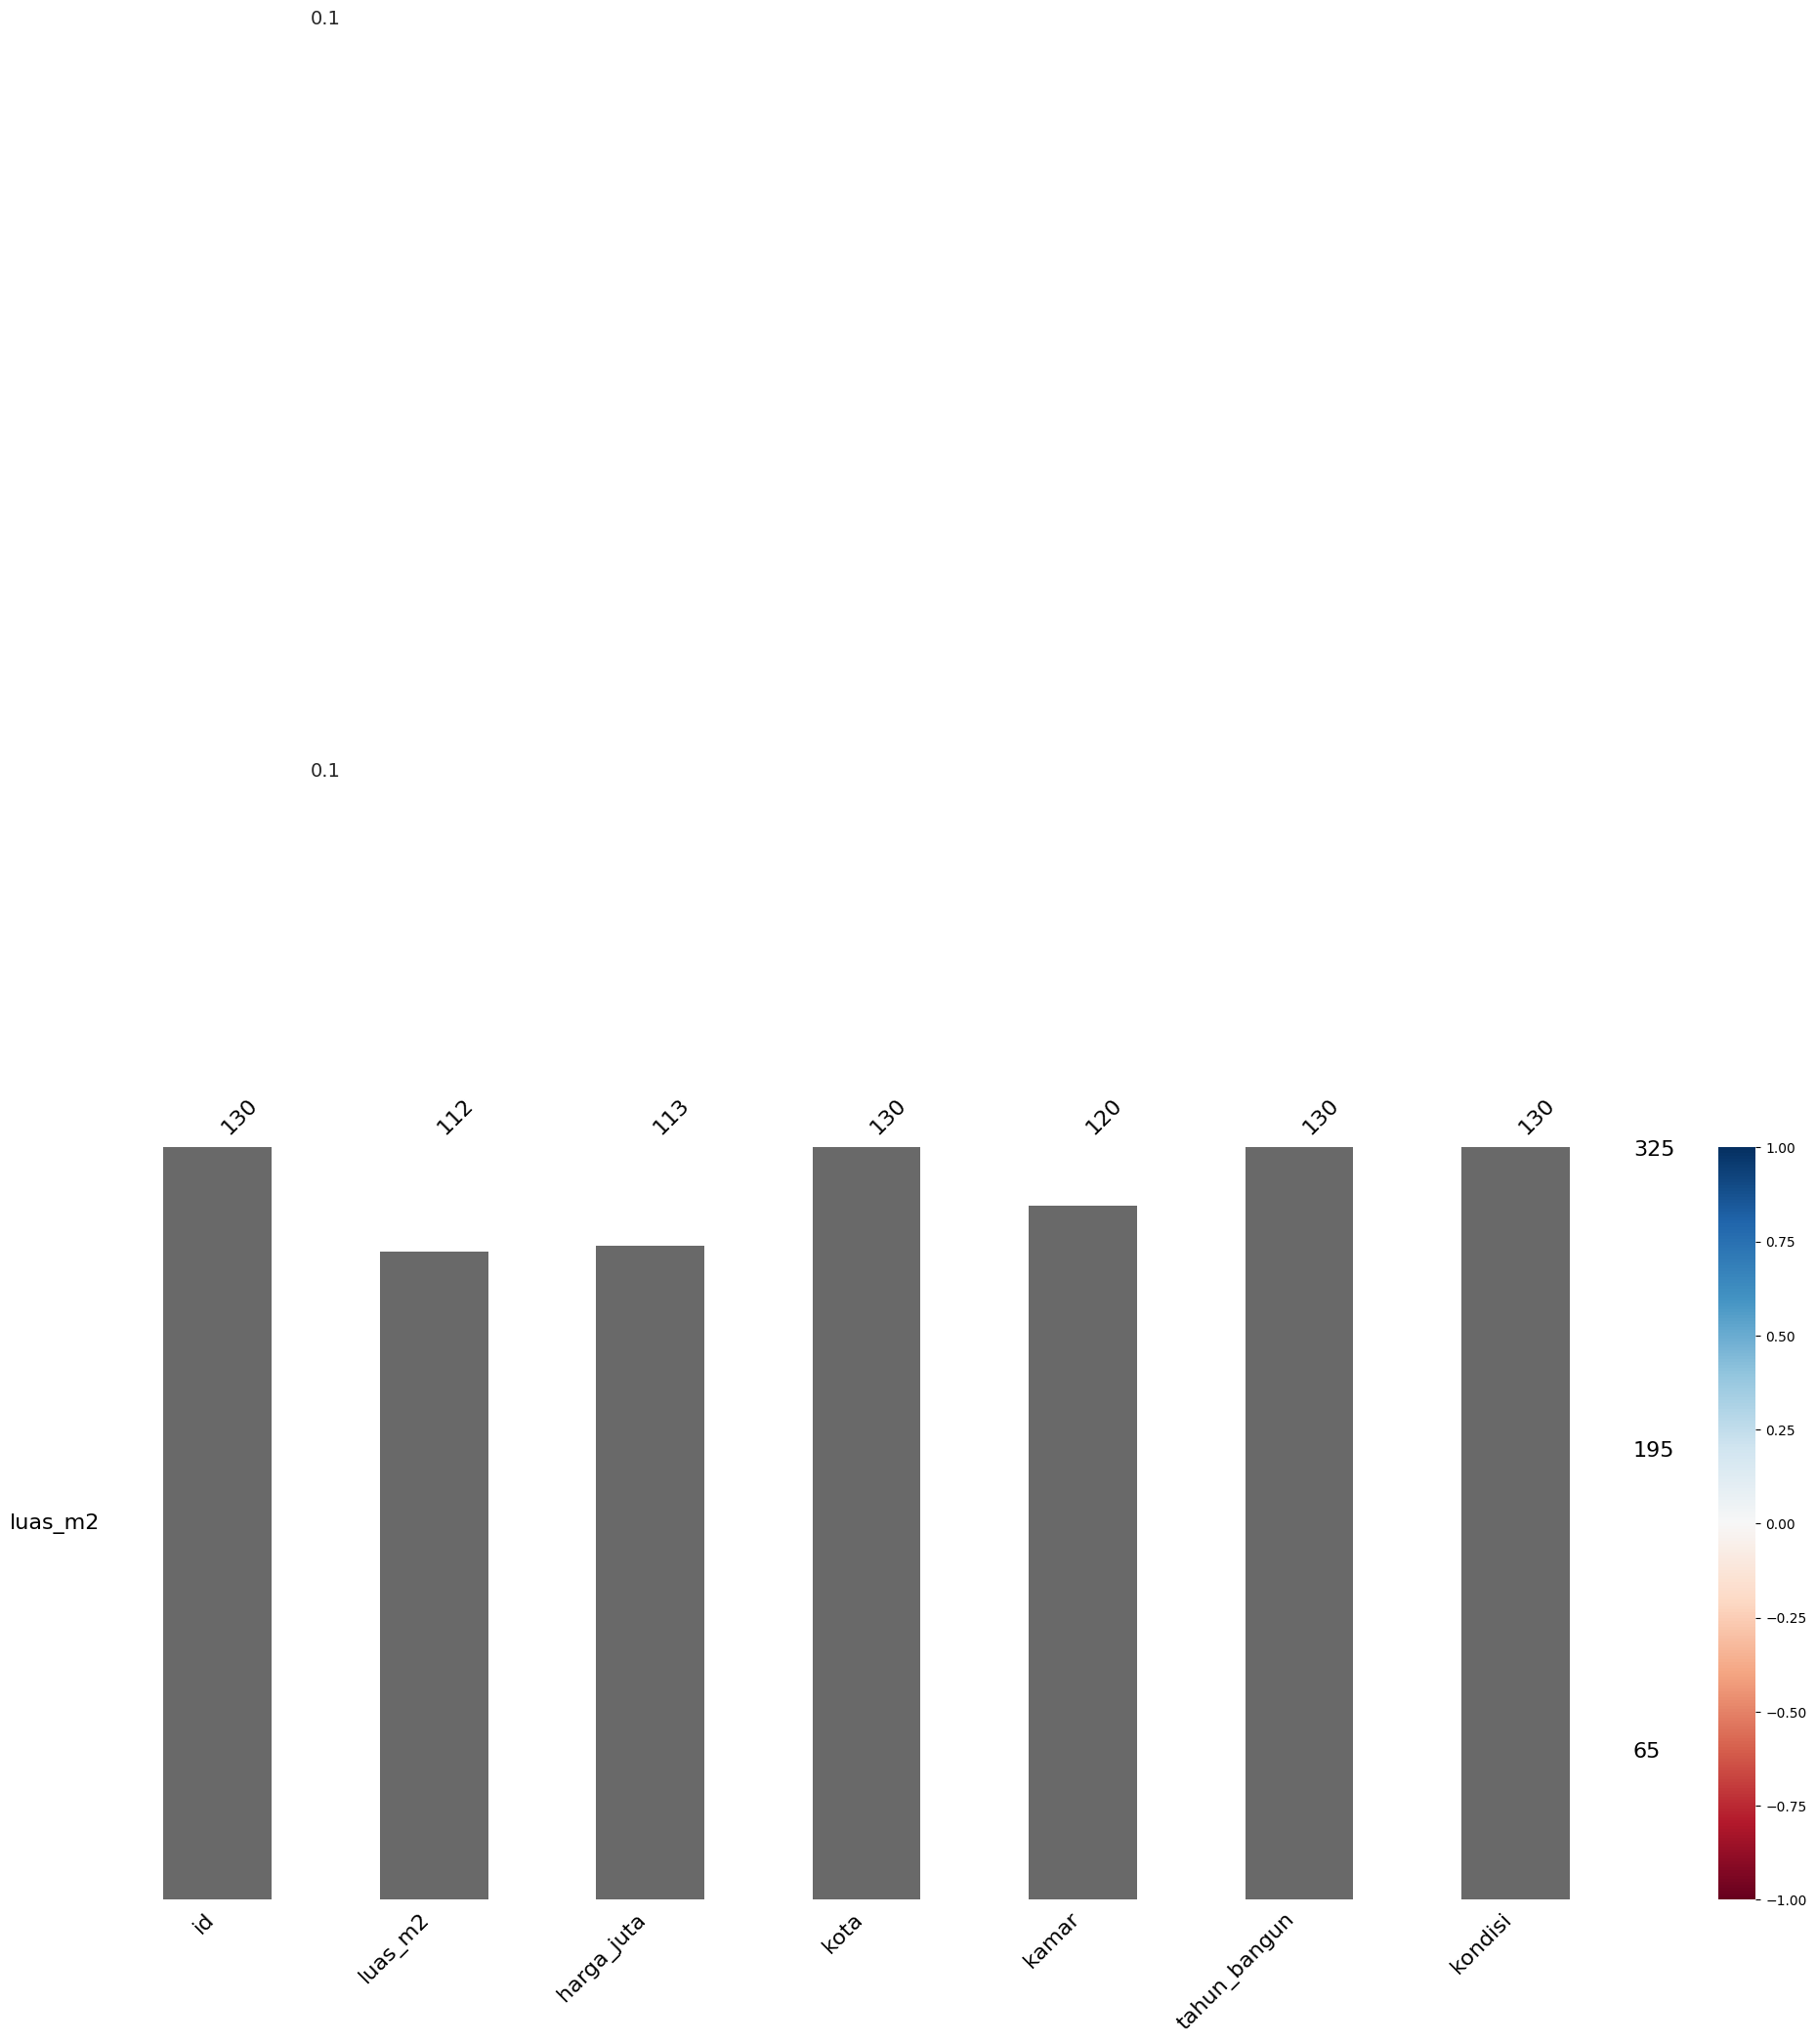

In [21]:
import pandas as pd, numpy as np
import missingno as msno # pip install missingno
df = pd.read_csv('housing_dirty.csv')

# Jumlah missing per kolom
print("Jumlah missing per kolom sebelum imputasi:")
print(df.isnull().sum())

# Proporsi (%) missing per kolom
pct = (df.isnull().sum() / len(df) * 100).round(2)
print("\nProporsi missing per kolom (yang > 0%):")
print(pct[pct > 0]) # tampilkan yang > 0%

# Identifikasi baris dengan SEMUA nilai missing
all_missing = df[df.isnull().all(axis=1)]

# Identifikasi kolom yang perlu di-drop (> 40% missing)
threshold = 0.4
cols_drop = df.columns[df.isnull().mean() > threshold]
df.drop(columns=cols_drop, inplace=True)

# Visualisasi pola missing (perlu matplotlib)
msno.matrix(df) # matrix visualisasi
msno.heatmap(df) # korelasi ketidaklengkapan

print(f"\nShape sebelum drop kolom: {pd.read_csv('housing_dirty.csv').shape}")
print(f"Shape setelah drop kolom: {df.shape}")

msno.bar(df) # Bar chart visualisasi missing per kolom setelah drop

##Python — Imputasi Missing Values
# Berdasarkan deteksi missing values sebelumnya, kolom 'luas_m2', 'harga_juta', dan 'kamar' memiliki nilai yang hilang.
# Kita akan mengisi nilai-nilai yang hilang ini menggunakan strategi imputasi median,
# karena median kurang sensitif terhadap outlier dibandingkan mean.

print('\nMedian sebelum imputasi:')
print(df[['luas_m2', 'harga_juta', 'kamar']].median())

# Imputasi missing values dengan median
df['luas_m2'].fillna(df['luas_m2'].median(), inplace=True)
df['harga_juta'].fillna(df['harga_juta'].median(), inplace=True)
df['kamar'].fillna(df['kamar'].median(), inplace=True)

print('\nJumlah missing values setelah imputasi:')
print(df[['luas_m2', 'harga_juta', 'kamar']].isnull().sum())

print('\nBeberapa baris pertama DataFrame setelah imputasi:')
display(df.head())


print("=" * 40)



##Python — Dropping Missing Values
# Bagian ini mendemonstrasikan berbagai strategi penghapusan missing values.
# Penting untuk dicatat bahwa setelah langkah imputasi median sebelumnya,
# DataFrame ini seharusnya sudah tidak memiliki missing values pada kolom 'luas_m2', 'harga_juta', dan 'kamar',
# serta tidak ada kolom yang melebihi threshold missing values yang ditetapkan.
# Oleh karena itu, operasi `dropna` berikut mungkin tidak akan mengubah DataFrame dalam kasus ini,
# tetapi disajikan sebagai ilustrasi strategi umum.

# Strategi 1: Drop baris yang memiliki ANY missing value
# df.dropna(inplace=True) # Di-comment karena sudah bersih

# Strategi 2: Drop baris hanya jika kolom tertentu missing
# Contoh: Drop baris jika 'harga_juta' atau 'luas_m2' missing.
# Karena kolom-kolom ini sudah diimputasi, operasi ini tidak akan menghapus baris di sini.
# df.dropna(subset=['harga_juta','luas_m2'], inplace=True) # Menggunakan nama kolom yang benar

# Strategi 3: Drop kolom: pertahankan jika >= 60% nilai ada (yaitu, drop jika > 40% missing)
# Karena kolom dengan >40% missing sudah didrop di awal dan yang lain diimputasi,
# ini kemungkinan tidak akan menghapus kolom lagi.
# df.dropna(thresh=int(len(df)*0.6), axis=1, inplace=True) # Di-comment karena sudah bersih

print("\nJumlah missing values akhir setelah semua proses (deteksi, drop kolom, dan imputasi):")
print(df.isnull().sum())

print(f"\nShape DataFrame akhir: {df.shape}")


print("=" * 40)



##Python — Imputasi Statistik (Strategi Alternatif)
# Bagian ini mendemonstrasikan berbagai strategi imputasi lainnya sebagai referensi.
# Perlu diingat bahwa DataFrame 'df' telah dibersihkan dari missing values
# di kolom-kolom utama melalui imputasi median di bagian sebelumnya.
# Oleh karena itu, operasi berikut ini tidak akan mengubah DataFrame saat ini,
# melainkan hanya menyajikan sintaks dan penjelasan penggunaannya.

# Imputasi Mean — untuk numerik, distribusi normal
# df['luas_m2'].fillna(df['luas_m2'].mean(), inplace=True)
# ^ Ini adalah contoh penggunaan, 'luas_m2' sudah bersih.

# Imputasi Median — untuk numerik, distribusi skewed (sudah dilakukan di awal untuk 'harga_juta' dan 'luas_m2')
# df['harga_juta'].fillna(df['harga_juta'].median(), inplace=True)
# ^ Ini adalah contoh penggunaan, 'harga_juta' sudah bersih.

# Imputasi Modus — untuk kategorik atau numerik diskrit
mode_kota = df['kota'].mode()[0]
# df['kota'].fillna(mode_kota, inplace=True)
# ^ Ini adalah contoh penggunaan, 'kota' tidak memiliki missing values.

# Forward fill (ffill) dan Backward fill (bfill) — untuk time-series
# df['suhu'].ffill(inplace=True) # Mengisi dari nilai sebelumnya
# df['suhu'].bfill(inplace=True) # Mengisi dari nilai berikutnya
# ^ Catatan: Kolom 'suhu' tidak ada di DataFrame saat ini. Metode ini cocok untuk data berurutan.

# Interpolasi linear — untuk data kontinyu
# df['harga_juta'].interpolate(method='linear', inplace=True)
# ^ Ini adalah contoh penggunaan, 'harga_juta' sudah bersih.
#   Metode ini mengisi missing values berdasarkan interpolasi antara nilai yang ada.

print("\n[Selesai] Demonstrasi strategi imputasi statistik alternatif.")
print("Jumlah missing values setelah demonstrasi:")
print(df.isnull().sum())
print(f"Shape DataFrame akhir: {df.shape}")

print("=" * 40)

##Python — KNN Imputer dan SimpleImputer
from sklearn.impute import KNNImputer, SimpleImputer

# Definisi kolom numerik untuk imputasi
numerik_cols = ['luas_m2', 'harga_juta', 'kamar', 'tahun_bangun']

# Karena DataFrame 'df' sudah bersih dari missing values setelah imputasi median sebelumnya,
# operasi KNNImputer berikut ini hanya bersifat demonstrasi bagaimana cara menggunakannya.
# Ini akan 'mengimputasi' nilai-nilai yang sudah ada dengan dirinya sendiri atau tetangganya.

print('\nDemonstrasi KNNImputer:')
# KNN Imputer — 5 tetangga terdekat
kNN = KNNImputer(n_neighbors=5)
df_knn_imputed = pd.DataFrame(
    knn.fit_transform(df[numerik_cols]),
    columns=numerik_cols,
    index=df.index # Penting untuk menjaga indeks agar bisa digabungkan nanti
)

print('Beberapa baris pertama DataFrame setelah KNN Imputer (pada kolom numerik):')
display(df_knn_imputed.head())

print('\nDemonstrasi SimpleImputer (mean):')
# SimpleImputer — Mengisi dengan nilai rata-rata (mean)
simple_imputer_mean = SimpleImputer(strategy='mean')
df_simple_imputed_mean = pd.DataFrame(
    simple_imputer_mean.fit_transform(df[numerik_cols]),
    columns=numerik_cols,
    index=df.index
)
print('Beberapa baris pertama DataFrame setelah SimpleImputer (mean) pada kolom numerik:')
display(df_simple_imputed_mean.head())

print('\n[Selesai] Demonstrasi Imputer Lanjutan.')
print("Jumlah missing values setelah semua demonstrasi:")
print(df.isnull().sum())
print(f"Shape DataFrame akhir: {df.shape}")

print("=" * 40)

##Python — Menangani Duplikat
# Deteksi: berapa baris yang duplikat?
n_dup = df.duplicated().sum()
print(f'{n_dup} baris duplikat dari {len(df)} total')
# Tampilkan baris yang duplikat (semua kemunculan)
df_dup = df[df.duplicated(keep=False)]
# Duplikat berdasarkan subset kolom kunci
df.duplicated(subset=['id', 'luas_m2'])

print("=" * 40)


##Python — IQR Fence Outlier Detection
def deteksi_outlier_iqr(df, kolom):
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[kolom]<lower)|(df[kolom]>upper)]
    return lower, upper, outliers
lower, upper, out_df = deteksi_outlier_iqr(df, 'harga_juta') # Corrected 'harga' to 'harga_juta'
print(f'Outlier: {len(out_df)} baris')
print(f'Batas: [{lower:.0f}, {upper:.0f}]')


print("=" * 40)


##Python — Z-Score Outlier Detection
from scipy import stats
numerik_cols = df.select_dtypes(include='number').columns
z_scores = np.abs(stats.zscore(df[numerik_cols].dropna()))
outlier_mask = (z_scores > 3).any(axis=1)
df_clean = df[~outlier_mask]
print(f'Baris dihapus: {outlier_mask.sum()}')


print("=" * 40)

##Python — Pipeline Cleaning Lengkap
# ============================================
# PIPELINE DATA CLEANING — HOUSING DATASET
# ============================================
import pandas as pd, numpy as np
from scipy.stats.mstats import winsorize
# STEP 0 — Load & eksplorasi awal
df = pd.read_csv('housing_dirty.csv')
print('Shape awal:', df.shape)
print(df.isnull().sum())
# STEP 1 — Hapus Duplikat
df.drop_duplicates(inplace=True)
print('Setelah hapus duplikat:', df.shape)
# STEP 2 — Normalisasi String
df['kota'] = df['kota'].str.strip().str.title()
df['kondisi'] = df['kondisi'].str.strip().str.lower()
# STEP 3 — Imputasi Missing Values
df['luas_m2'] = df['luas_m2'].fillna(df['luas_m2'].median())
df['harga_juta'] = df['harga_juta'].fillna(df['harga_juta'].median())
df['kamar'] = df['kamar'].fillna(df['kamar'].mode()[0])
# STEP 4 — Tangani Outlier (IQR Fence)
for col in ['harga_juta', 'luas_m2', 'tahun_bangun']:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1-1.5*IQR, Q3+1.5*IQR)

# STEP 5 — Validasi & Ekspor
assert df.isnull().sum().sum() == 0, 'Masih ada missing!'
assert df.duplicated().sum() == 0, 'Masih ada duplikat!'
print('Shape akhir:', df.shape)
df.to_csv('housing_clean.csv', index=False)
print('Dataset bersih tersimpan!')


##SELESAI

## Ringkasan Latihan Pemrosesan Data

### Apa yang Dipelajari:
Dalam latihan ini, kita telah melakukan serangkaian langkah pra-pemrosesan data untuk membersihkan dataset `housing_dirty.csv`:
1.  **Deteksi dan Penanganan Missing Values**: Mengidentifikasi, memvisualisasikan pola missing values menggunakan `missingno`, dan melakukan imputasi median untuk kolom numerik (`luas_m2`, `harga_juta`, `kamar`). Berbagai strategi imputasi alternatif (mean, mode, ffill, bfill, interpolasi, KNN Imputer, SimpleImputer) juga didemonstrasikan.
2.  **Penanganan Duplikat**: Mendeteksi dan menghapus baris duplikat penuh serta duplikat berdasarkan subset kolom kunci (`id`, `luas_m2`).
3.  **Normalisasi Data Teks**: Melakukan normalisasi string pada kolom kategorikal (`kota`, `kondisi`) untuk konsistensi.
4.  **Deteksi dan Penanganan Outlier**: Mengidentifikasi outlier menggunakan metode IQR Fence dan Z-Score, kemudian menanganinya dengan capping (winsorization) menggunakan batas IQR.
5.  **Pembangunan Pipeline Pembersihan Data**: Menggabungkan semua langkah pra-pemrosesan ke dalam sebuah pipeline yang terstruktur untuk memastikan data bersih dan siap digunakan.
6.  **Validasi dan Ekspor**: Memvalidasi integritas data (tidak ada missing values atau duplikat) dan mengekspor dataset yang sudah bersih ke `housing_clean.csv`.

### Temuan Utama:
*   Dataset awal memiliki missing values di `luas_m2`, `harga_juta`, dan `kamar`, yang berhasil diatasi melalui imputasi median.
*   Terdapat duplikat dalam data yang berhasil dihapus, meningkatkan kualitas dataset.
*   Identifikasi dan penanganan outlier membantu menghasilkan distribusi data yang lebih robust untuk analisis lebih lanjut.
*   Normalisasi string memastikan konsistensi dan kebersihan data kategorikal.

### Tools/Library yang Digunakan:
*   `pandas` untuk manipulasi dan analisis data.
*   `numpy` untuk operasi numerik.
*   `missingno` untuk visualisasi missing values.
*   `sklearn.impute.KNNImputer` dan `sklearn.impute.SimpleImputer` untuk imputasi missing values lanjutan.
*   `scipy.stats` (khususnya `zscore` dan `winsorize` dari `scipy.stats.mstats`) untuk deteksi dan penanganan outlier.